In [1]:
import arviz as az
import pymc as pm
from matplotlib import pyplot as plt
import hssm
import pandas as pd
from hssm.likelihoods import DDM
import pytensor 
import pytensor.tensor as pt
from pytensor.graph.op import Op 
import pickle as pkl 
import numpy as np
import time 
from scipy.optimize import fmin, minimize, LinearConstraint, Bounds 
from efficient_fpt.multi_stage_cy import (compute_loss_parallel, print_num_threads, compute_glamloss_parallel)
import jax 
import jax.numpy as jnp 
from jax import grad,jit,vmap 

# print(f"PyMC version: {pm.__version__}")
# print(f"JAX version: {jax.__version__}")
# print(f"JAX devices: {jax.devices()}")

In [2]:
# Simulate data 
NUM_TRIALS = 500     # Number of trials to simulate
RANDOM_SEED = 42       # For reproducibility

# True parameters for data generation
TRUE_PARAMS = {
    'eta': 0.7,        # Attention discount factor (0-1)
    'kappa': 0.5,      # Drift scaling
    'a': 2.1,          # Initial boundary
    'b': 0.3,          # Boundary collapse rate
    'x0': -0.2,        # Starting position
    'sigma': 1.0,      # Diffusion coefficient (fixed)
}

# Fixation time distribution parameters (Gamma)
FIXATION_SHAPE = 6
FIXATION_SCALE = 0.1

print(f"Simulating {NUM_TRIALS} trials with:")
for k, v in TRUE_PARAMS.items():
    print(f"  {k} = {v}")

# Import simulator
from efficient_fpt.models import DDModel, piecewise_const_func
from efficient_fpt.utils import get_alternating_mu_array

class aDDModel(DDModel):
    """Attentional Drift Diffusion Model for a single trial."""
    def __init__(self, mu1, mu2, sacc_array, flag, sigma, a, b, x0):
        super().__init__(x0)
        self.mu1 = mu1
        self.mu2 = mu2
        self.sacc_array = sacc_array
        self.flag = flag  # 0: start with mu1, 1: start with mu2
        self.d = len(sacc_array)
        self.mu_array = get_alternating_mu_array(mu1, mu2, self.d, flag)
        self.sigma = sigma
        self.a = a
        self.b = b

    def drift_coeff(self, X, t):
        return piecewise_const_func(t, self.mu_array, self.sacc_array)

    def diffusion_coeff(self, X, t):
        return self.sigma

    @property
    def is_update_vectorizable(self):
        return True

    def upper_bdy(self, t):
        return self.a - self.b * t

    def lower_bdy(self, t):
        return -self.a + self.b * t

def simulate_trial(rng, eta, kappa, sigma, a, b, x0, T_max, shape, scale):
    """Simulate a single aDDM trial."""
    # Generate fixation times
    fixations = rng.gamma(shape, scale, 100)
    sacc_array = np.insert(np.cumsum(fixations), 0, 0)
    sacc_array = sacc_array[sacc_array < T_max]
    
    # Random initial attention and stimulus values
    flag = rng.integers(0, 2)
    r1 = rng.integers(1, 6)
    r2 = rng.integers(1, 6)
    
    # Compute drift rates
    mu1 = kappa * (r1 - eta * r2)
    mu2 = kappa * (eta * r1 - r2)
    
    # Simulate
    model = aDDModel(mu1, mu2, sacc_array, flag, sigma, a, b, x0)
    rt, choice = model.simulate_fpt_datum(dt=1e-4)
    
    # Truncate saccade array to actual RT
    sacc_array = sacc_array[sacc_array < rt]
    d = len(sacc_array)
    mu_array = get_alternating_mu_array(mu1, mu2, d, flag)
    
    return {
        'rt': rt,
        'choice': int(choice),
        'mu_array': mu_array,
        'sacc_array': sacc_array,
        'd': d,
        'r1': r1,
        'r2': r2,
        'flag': flag,
        'mu1': mu1,
        'mu2': mu2,
    }

# Simulate data
print(f"Simulating {NUM_TRIALS} trials...")
rng = np.random.default_rng(RANDOM_SEED)
T_max = TRUE_PARAMS['a'] 

start = time.time()
trials = []
for i in range(NUM_TRIALS):
    if (i + 1) % 200 == 0:
        print(f"  {i+1}/{NUM_TRIALS}...")
    trial = simulate_trial(
        rng, TRUE_PARAMS['eta'], TRUE_PARAMS['kappa'], 
        TRUE_PARAMS['sigma'], TRUE_PARAMS['a'], TRUE_PARAMS['b'], 
        TRUE_PARAMS['x0'], T_max, FIXATION_SHAPE, FIXATION_SCALE
    )
    trials.append(trial)

print(f"Simulation completed in {time.time() - start:.1f}s")



Simulating 500 trials with:
  eta = 0.7
  kappa = 0.5
  a = 2.1
  b = 0.3
  x0 = -0.2
  sigma = 1.0
Simulating 500 trials...
  200/500...
  400/500...
Simulation completed in 163.1s


In [5]:
# Prepare data arrays
rt_data = np.array([t['rt'] for t in trials], dtype=np.float64)
choice_data = np.array([t['choice'] for t in trials], dtype=np.int32)
d_data = np.array([t['d'] for t in trials], dtype=np.int32)
r1_data = np.array([t['r1'] for t in trials], dtype=np.float64)
r2_data = np.array([t['r2'] for t in trials], dtype=np.float64)
flag_data = np.array([t['flag'] for t in trials], dtype=np.int32)
mu1_data = np.array([t['mu1'] for t in trials], dtype=np.float64)
mu2_data = np.array([t['mu2'] for t in trials], dtype=np.float64)

# Pad arrays to max length
max_d = max(d_data)
mu_data_padded = np.zeros((NUM_TRIALS, max_d), dtype=np.float64)
sacc_data_padded = np.zeros((NUM_TRIALS, max_d), dtype=np.float64)

for i, t in enumerate(trials):
    d = t['d']
    mu_data_padded[i, :d] = t['mu_array']
    sacc_data_padded[i, :d] = t['sacc_array']

print(f"Data summary:")
print(f"  Trials: {NUM_TRIALS}")
print(f"  Max stages: {max_d}")
print(f"  Mean stages: {np.mean(d_data):.1f}")
print(f"  RT range: [{rt_data.min():.2f}, {rt_data.max():.2f}]")
print(f"  Upper choices: {np.sum(choice_data == 1)} ({100*np.mean(choice_data == 1):.1f}%)")


Data summary:
  Trials: 500
  Max stages: 6
  Mean stages: 2.9
  RT range: [0.25, 5.13]
  Upper choices: 227 (45.4%)


In [1]:
import ssms 
from ssms import Simulator 
addm = Simulator("addm")
addm_out = addm.simulate(theta={"eta": 0.7, "kappa": 0.5, "a": 2.1, "z": -0.2, "b":0.3, "t": 0.0},
                        n_samples=500)

NameError: name 'rt_data' is not defined

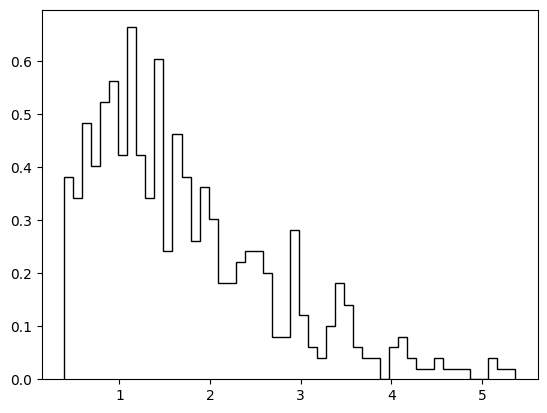

In [3]:
plt.hist(
    addm_out["rts"],
    bins=50,
    histtype="step",
    color="black",
    label="Weibull Deadline",
    density=True,
)
plt.hist(
    rt_data,
    bins=100,
    histtype="step",
    color="red",
    label="ADDm with eta=0.25",
    density=True,
)